In [ ]:
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, Rectangle
from matplotlib.animation import FuncAnimation, PillowWriter

In [14]:
fn_les = r"..\data\test_les_data\Flowpos_05D.nc"

### Open LES data

In [15]:
ds_les = xr.open_dataset(fn_les)
ds_les

<xarray.Dataset> Size: 12MB
Dimensions:  (t: 60, z: 64, y: 128, x: 1, U0: 1, TI0: 1, R: 1, Prated: 1,
              zHub: 1)
Coordinates:
  * t        (t) float64 480B 1.001e+03 1.002e+03 ... 1.059e+03 1.06e+03
  * z        (z) float64 512B -165.6 -156.5 -147.5 -138.5 ... 384.4 393.4 402.4
  * y        (y) float64 1kB -705.6 -696.6 -687.7 -678.7 ... 412.5 421.5 430.4
  * x        (x) float64 8B 1.42e+03
  * U0       (U0) float64 8B 9.22
  * TI0      (TI0) float64 8B 0.038
  * R        (R) float64 8B 142.0
  * Prated   (Prated) float64 8B 2.2e+04
  * zHub     (zHub) float64 8B 170.0
Data variables:
    V        (t, z, y, x) float64 4MB ...
    W        (t, z, y, x) float64 4MB ...
    U        (t, z, y, x) float64 4MB ...

### Instantaneous wind speed field (streamwise)

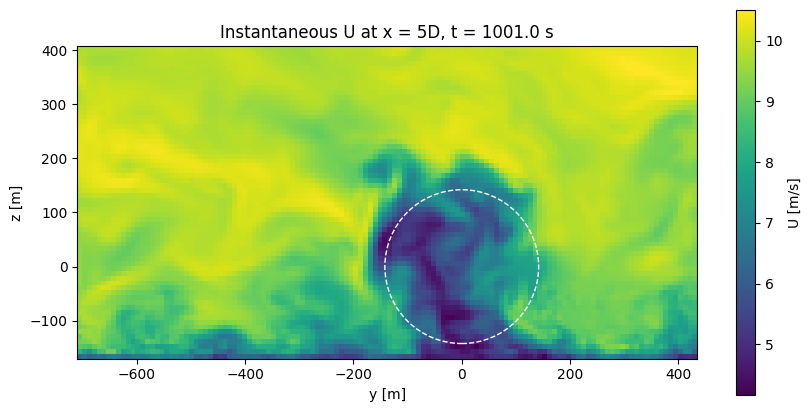

In [16]:

t_plot = 1000.0  # [s], snapped to the nearest available time step

U_t = ds_les["U"].sel(t=t_plot, method="nearest").squeeze("x")
R = ds_les["R"].item()

fig, ax = plt.subplots(figsize=(10, 5))
U_t.plot.pcolormesh(x="y", y="z", ax=ax, cmap="viridis",
                    cbar_kwargs={"label": "U [m/s]"})

# Rotor disk outline (assumes y, z are relative to the rotor centre)
ax.add_patch(Circle((0, 0), R, fill=False, edgecolor="white",
                    linestyle="--", linewidth=1))

ax.set_aspect("equal")
ax.set_xlabel("y [m]")
ax.set_ylabel("z [m]")
ax.set_title(f"Instantaneous U at x = {(ds_les.x.item()/(2*R)):.0f}D, t = {U_t.t.item():.1f} s")
plt.show()

### Animation of the wind speed field (streamwise)

In [ ]:
t_start, t_end = 1000.0, 1060.0  # [s] time window to animate
stride = 1                       # use every n-th time step
fps = 10

R = ds_les["R"].item()
fn_gif = Path(f"../plots/les_U_yz_{(ds_les.x.item()/(2*R)):.1f}D_animation.gif")

# Load only the frames needed into memory
U_anim = ds_les["U"].sel(t=slice(t_start, t_end)).isel(t=slice(None, None, stride)).squeeze("x").load()

# Fixed colour limits so frames are comparable
vmin, vmax = np.nanpercentile(U_anim.values, [1, 99])

fig, ax = plt.subplots(figsize=(10, 5))
mesh = ax.pcolormesh(U_anim.y, U_anim.z, U_anim.isel(t=0).values,
                     cmap="viridis", vmin=vmin, vmax=vmax, shading="auto")
fig.colorbar(mesh, ax=ax, label="U [m/s]")

# Rotor disk outline (assumes y, z are relative to the rotor centre)
ax.add_patch(Circle((0, 0), R, fill=False, edgecolor="white",
                    linestyle="--", linewidth=1))

ax.set_aspect("equal")
ax.set_xlabel("y [m]")
ax.set_ylabel("z [m]")
title = ax.set_title("")

def update(i):
    mesh.set_array(U_anim.isel(t=i).values.ravel())
    title.set_text(f"Instantaneous U at x = {(ds_les.x.item()/(2*R)):.0f}D, t = {U_anim.t[i].item():.1f} s")
    return mesh, title

anim = FuncAnimation(fig, update, frames=U_anim.sizes["t"], blit=False)

# Save as GIF; it is displayed by the markdown cell below, which also renders on GitHub
anim.save(fn_gif, writer=PillowWriter(fps=fps), dpi=80)
plt.close(fig)  # avoid showing an extra static figure
print(f"Saved {fn_gif}")

**x = 5D**

![Instantaneous U at x = 5D](../plots/les_U_yz_5.0D_animation.gif)

**x = 10D**

![Instantaneous U at x = 10D](../plots/les_U_yz_10.0D_animation.gif)

### Mean wind speed field (streamwise)

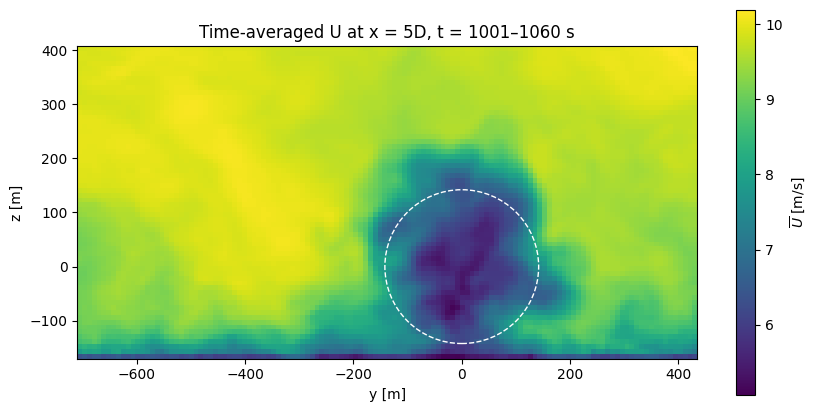

In [18]:
U_mean = ds_les["U"].mean(dim="t").squeeze("x")

R = ds_les["R"].item()
fig, ax = plt.subplots(figsize=(10, 5))
U_mean.plot.pcolormesh(x="y", y="z", ax=ax, cmap="viridis",
                       cbar_kwargs={"label": r"$\overline{U}$ [m/s]"})

# Rotor disk outline (assumes y, z are relative to the rotor centre)
ax.add_patch(Circle((0, 0), R, fill=False, edgecolor="white",
                    linestyle="--", linewidth=1))

ax.set_aspect("equal")
ax.set_xlabel("y [m]")
ax.set_ylabel("z [m]")
ax.set_title(f"Time-averaged U at x = {(ds_les.x.item()/(2*R)):.0f}D, "
             f"t = {ds_les.t[0].item():.0f}–{ds_les.t[-1].item():.0f} s")
plt.show()

### TI field (streamwise)

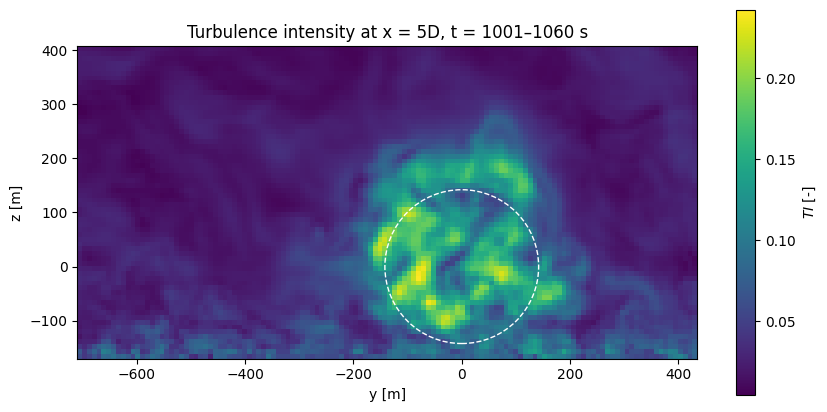

In [19]:
R = ds_les["R"].item()

U_mean = ds_les["U"].mean(dim="t").squeeze("x")
U_std = ds_les["U"].std(dim="t").squeeze("x")
TI = U_std / U_mean

fig, ax = plt.subplots(figsize=(10, 5))
TI.plot.pcolormesh(x="y", y="z", ax=ax, cmap="viridis",
                       cbar_kwargs={"label": r"$TI$ [-]"})

# Rotor disk outline (assumes y, z are relative to the rotor centre)
ax.add_patch(Circle((0, 0), R, fill=False, edgecolor="white",
                    linestyle="--", linewidth=1))

ax.set_aspect("equal")
ax.set_xlabel("y [m]")
ax.set_ylabel("z [m]")
ax.set_title(f"Turbulence intensity at x = {(ds_les.x.item()/(2*R)):.0f}D, "
             f"t = {ds_les.t[0].item():.0f}–{ds_les.t[-1].item():.0f} s")
plt.show()

### hub-height x-y plane 

In [ ]:
fn_les_hh = r"..\data\test_les_data\Flowpos_hubheightplane.nc"
#fn_les_hh = r"..\data\temp\Flowpos_hubheightplane.nc"

In [9]:
ds_les_hh = xr.open_dataset(fn_les_hh)
ds_les_hh

<xarray.Dataset> Size: 177MB
Dimensions:  (t: 60, z: 1, y: 192, x: 640, U0: 1, TI0: 1, R: 1, Prated: 1,
              zHub: 1)
Coordinates:
  * t        (t) float64 480B 1.001e+03 1.002e+03 ... 1.059e+03 1.06e+03
  * z        (z) float64 8B 0.0
  * y        (y) float64 2kB -847.6 -838.7 -829.8 -820.9 ... 829.8 838.7 847.6
  * x        (x) float64 5kB -989.6 -980.7 -971.8 ... 4.673e+03 4.682e+03
  * U0       (U0) float64 8B 9.22
  * TI0      (TI0) float64 8B 0.038
  * R        (R) float64 8B 142.0
  * Prated   (Prated) float64 8B 2.2e+04
  * zHub     (zHub) float64 8B 170.0
Data variables:
    U        (t, z, y, x) float64 59MB ...
    V        (t, z, y, x) float64 59MB ...
    W        (t, z, y, x) float64 59MB ...

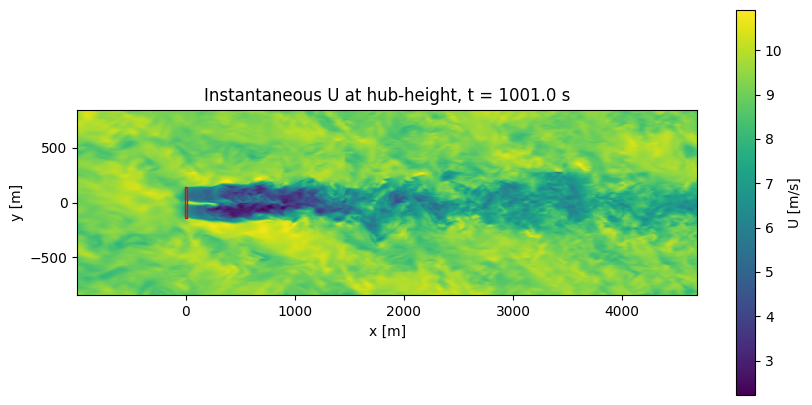

In [10]:
t_plot = 1000.0  # [s], snapped to the nearest available time step

U_t_hh = ds_les_hh["U"].sel(t=t_plot, method="nearest").squeeze("z")
R = ds_les_hh["R"].item()

fig, ax = plt.subplots(figsize=(10, 5))
U_t_hh.plot.pcolormesh(x="x", y="y", ax=ax, cmap="viridis",
                    cbar_kwargs={"label": "U [m/s]"})

# Rotor seen from above (assumes the rotor is at x = 0, y = 0)
rotor_thickness = 20.0  # [m], visual thickness only
ax.add_patch(Rectangle((-rotor_thickness / 2, -R), rotor_thickness, 2 * R,
                       fill=False, edgecolor="red", linestyle="-",
                       linewidth=1))

ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title(f"Instantaneous U at hub-height, t = {U_t_hh.t.item():.1f} s")
plt.show()

In [ ]:
t_start, t_end = 1000.0, 1010.0  # [s] time window to animate
stride = 1                       # use every n-th time step
fps = 10
fn_gif = Path("../plots/les_U_hubheight_animation.gif")

R = ds_les_hh["R"].item()
# Load only the frames needed into memory
U_anim = ds_les_hh["U"].sel(t=slice(t_start, t_end)).isel(t=slice(None, None, stride)).squeeze("z").load()

# Fixed colour limits so frames are comparable
vmin, vmax = np.nanpercentile(U_anim.values, [1, 99])

fig, ax = plt.subplots(figsize=(10, 5))
mesh = ax.pcolormesh(U_anim.x, U_anim.y, U_anim.isel(t=0).values,
                     cmap="viridis", vmin=vmin, vmax=vmax, shading="auto")
fig.colorbar(mesh, ax=ax, label="U [m/s]")

# Rotor seen from above (assumes the rotor is at x = 0, y = 0)
rotor_thickness = 20.0  # [m], visual thickness only
ax.add_patch(Rectangle((-rotor_thickness / 2, -R), rotor_thickness, 2 * R,
                       fill=False, edgecolor="red", linestyle="-",
                       linewidth=1))

ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
title = ax.set_title("")

def update(i):
    mesh.set_array(U_anim.isel(t=i).values.ravel())
    title.set_text(f"Instantaneous U at hub-height, t = {U_anim.t[i].item():.1f} s")
    return mesh, title

anim = FuncAnimation(fig, update, frames=U_anim.sizes["t"], blit=False)

# Save as GIF; it is displayed by the markdown cell below, which also renders on GitHub
anim.save(fn_gif, writer=PillowWriter(fps=fps), dpi=80)
plt.close(fig)  # avoid showing an extra static figure
print(f"Saved {fn_gif}")

![Instantaneous U at hub height](../plots/les_U_hubheight_animation.gif)